# PROJET MACHINE LEARNING

Réalisé par :
- Moustapha Youssouf Sall
- Mouhamed Moustapha SY

Contexte :
- Mettre en place une solution IA, qui permet d’automatiser l’identification des
patients diabétiques en fonction de leurs caractéristiques, serait une solution
Innovante dans le domaine de la santé.

Objectifs :
- On veut mettre en place un modèle d’IA basé sur les modèles de machine
Learning pour identifier a priori la maladie diabétique chez les patients en se
basant sur leurs caractéristiques.

## Importation des packages

In [180]:
import pandas as pd #permet de charger et de manipuler les donnees
import numpy as np # permet de faire des calculs scientifiques et des conversions
import matplotlib.pyplot as plt # permet de faire des representations graphiques
import seaborn as sns # visualiser des donnees
import plotly.express as px #pour la partie data visualisation
from sklearn.preprocessing import  MinMaxScaler #normalisation des donnees
from sklearn.preprocessing import StandardScaler #representer les donnees dans l'intervalle [0.1]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression # permet de créer un model de regresion par classification
from sklearn.metrics import mean_squared_error, r2_score #evaluer les performances.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC #quand le modele est de type classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Import des métriques d'évaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score)

### Chargement des jeux de données

In [181]:
df =pd.read_csv("diabetes.csv") 
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Pour vérifier la fin du fichier CSV et contrôler les dernières observations on va utiliser 'tail()'

In [182]:
df.tail() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


On va voir des statistiques descriptives pour notre dataframe pour une vision plus claire 

In [183]:
df.describe() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [185]:
df["Outcome"].describe()

count    768.000000
mean       0.348958
std        0.476951
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Outcome, dtype: float64

In [186]:
# lister la valeur de cette variable
len(df['Outcome'].unique())

2

In [187]:
import sidetable

In [188]:
df.stb.missing()

,missing,total,percent
Pregnancies,0,768,0.0
Glucose,0,768,0.0
BloodPressure,0,768,0.0
SkinThickness,0,768,0.0
Insulin,0,768,0.0
BMI,0,768,0.0
DiabetesPedigreeFunction,0,768,0.0
Age,0,768,0.0
Outcome,0,768,0.0


affichage de la dimension (nbre de lignes et de colonnes)

In [189]:
df.shape

(768, 9)

In [190]:
# Calculs
Diabétique = len(df[df['Outcome'] == 1])
Non_Diabétique = len(df[df['Outcome'] == 0])

total_P = Diabétique + Non_Diabétique
Diabétique_percent = (Diabétique / total_P) * 100

# Affichage 
print(f"\n Nombre Total des patients : {total_P}")
print(f"\n Nombre de patients Diabétiques : {Diabétique}")
print(f"\n Nombre de patients Non Diabétiques : {Non_Diabétique}")
print(f"\n Pourcentage des patients Diabétiques : {Diabétique_percent:.2f}%")


 Nombre Total des patients : 768

 Nombre de patients Diabétiques : 268

 Nombre de patients Non Diabétiques : 500

 Pourcentage des patients Diabétiques : 34.90%


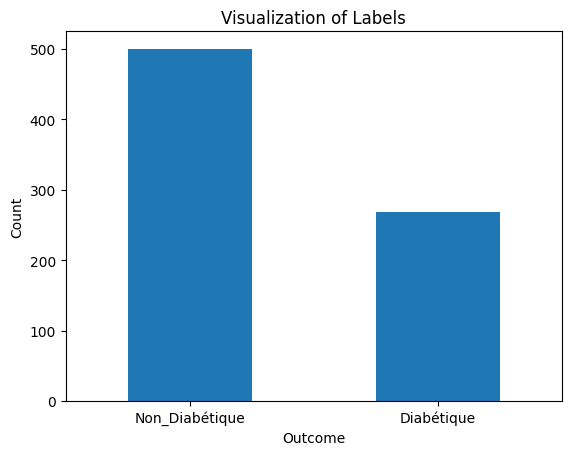

In [191]:
# Visualiser les 'labels' colonnes de notre dataset 

labels = ["Non_Diabétique", "Diabétique"]
count_classes = df.value_counts(df['Outcome'], sort= True)
count_classes.plot(kind = "bar", rot = 0)
plt.title("Visualization of Labels")
plt.ylabel("Count")
plt.xticks(range(2), labels)
plt.show()

On constate que les patients Non_Diabétique sont largement majoritaire aux patients Diabétique

### Lister les différents modèles

Comme il s'agit d'un problème de classification (prédire si un patient est diabétique ou non, soit 1 ou 0),
voici les modèles classiques utilisables :

- Régression Logistique : Un modèle de base pour la classification binaire.

- K-Nearest Neighbors (KNN) : Basé sur la proximité des données.

- Support Vector Machine (SVM) : Efficace pour séparer les classes dans des espaces complexes.

- Arbres de Décision (Decision Tree) : Modèle simple et interprétable.

- Random Forest : Un ensemble d'arbres de décision pour plus de précision.

### Préparation des données (Data Cleaning)

Avant d'entraîner les modèles, il faut nettoyer le jeu de données.

1. Vérification des valeurs manquantes

In [192]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dans le Dataset on constate qu'on a pas de valeurs manquantes .

 Vérification des doublons

In [193]:
df.duplicated().sum()

np.int64(0)

Les valeurs aberantes

<Axes: ylabel='Glucose'>

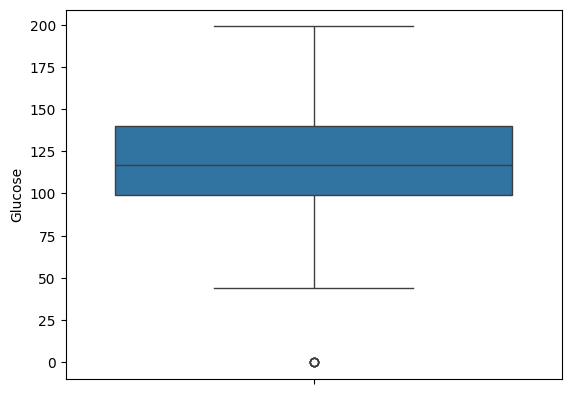

In [194]:
sns.boxplot(df['Glucose'])

<Axes: ylabel='BloodPressure'>

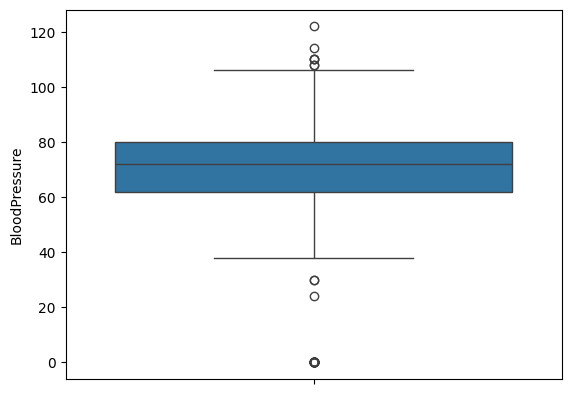

In [195]:
sns.boxplot(df['BloodPressure'])

<Axes: ylabel='SkinThickness'>

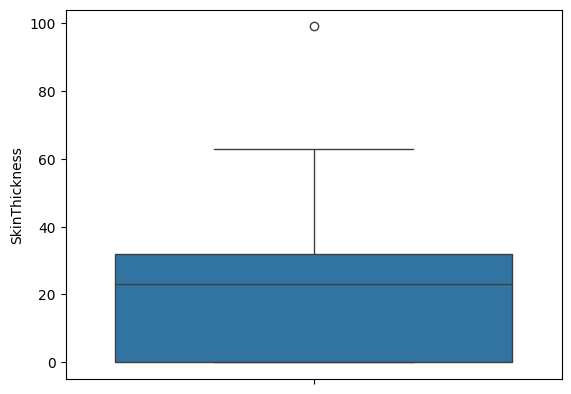

In [196]:
sns.boxplot(df['SkinThickness'])

<Axes: ylabel='Insulin'>

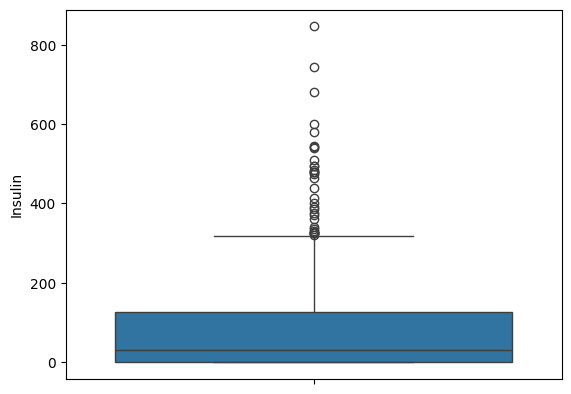

In [197]:
sns.boxplot(df['Insulin'])

<Axes: ylabel='BMI'>

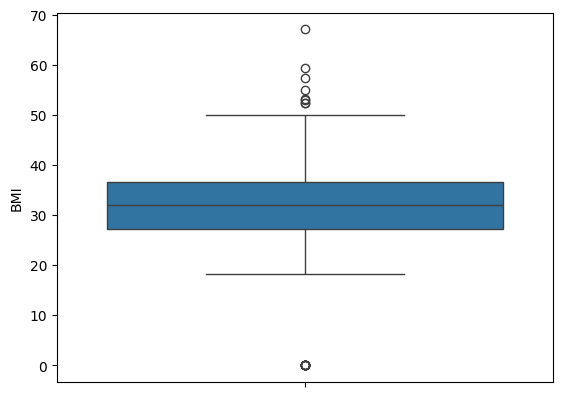

In [198]:
sns.boxplot(df['BMI'])

Ici on peut remarquer qu'on des valeurs aberantes  

### Correction des valeurs aberentes :

Méthode utilisée : Winsorizing (Capping IQR)
Toute valeur en dessous de la borne inférieure est ramenée à cette borne, 
et toute valeur au dessus de la borne supérieure est ramenée à cette borne. On ne supprime aucune ligne.

Fonctionnement :

On calcule les bornes via la règle IQR :

- Borne inférieure = Q1 − 1.5 × IQR
- Borne supérieure = Q3 + 1.5 × IQR

En classification, les outliers extrêmes peuvent biaiser les frontières de décision du modèle 
(surtout pour la régression logistique, SVM, KNN). Le Winsorizing réduit cet effet tout en gardant
l'information de direction (une valeur haute reste haute, juste plafonnée.

In [217]:
# NETTOYAGE et création de df_clean
df_clean = df.copy()

# Étape 1 : Zéros biologiquement impossibles → NaN puis imputation par médiane groupée
bio_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in bio_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

for col in bio_cols:
    medians = df_clean.groupby('Outcome')[col].median()
    for outcome_val in [0, 1]:
        mask = (df_clean['Outcome'] == outcome_val) & (df_clean[col].isna())
        df_clean.loc[mask, col] = medians[outcome_val]

In [218]:
# Étape 2 : Winsorizing (capping IQR ×1.5)
outlier_cols = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inferieure = max(0, Q1 - 1.5 * IQR)  
    borne_superieure = Q3 + 1.5 * IQR           
    df_clean[col] = df_clean[col].clip(lower=borne_inferieure, upper=borne_superieure)

print(" df_clean créé, shape:", df_clean.shape)

 df_clean créé, shape: (768, 9)


### Création de deux Figures (Avant et Après le correction)

FIGURE 1 — BOXPLOTS AVANT LA CORRECTION

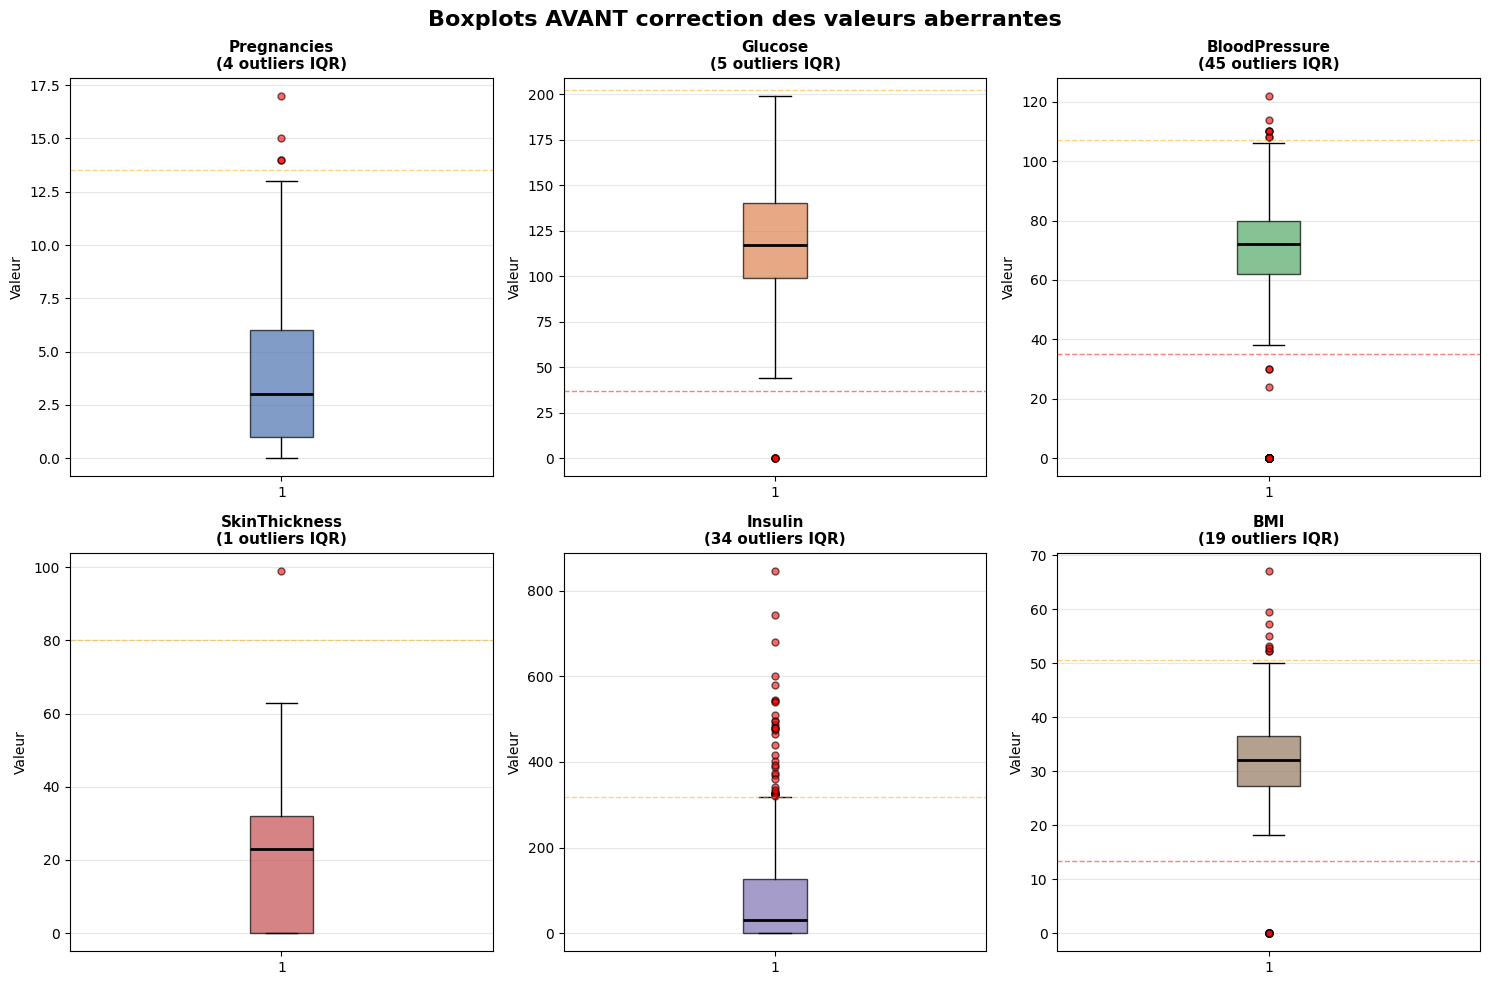

In [219]:
colonnes = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
couleurs = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplots AVANT correction des valeurs aberrantes', fontsize=16, fontweight='bold')

for i, (col, ax) in enumerate(zip(colonnes, axes.flatten())):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inferieure = max(0, Q1 - 1.5 * IQR)  
    borne_superieure = Q3 + 1.5 * IQR           
    n_outliers = ((df[col] < borne_inferieure) | (df[col] > borne_superieure)).sum()

    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=couleurs[i], alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6))

    ax.set_title(f'{col}\n({n_outliers} outliers IQR)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=borne_superieure, color='orange', linestyle='--', alpha=0.5, linewidth=1, label='Borne sup')
    if borne_inferieure > 0:
        ax.axhline(y=borne_inferieure, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Borne inf')

plt.tight_layout()
plt.show()

FIGURE 2 — BOXPLOTS APRES LA CORRECTION

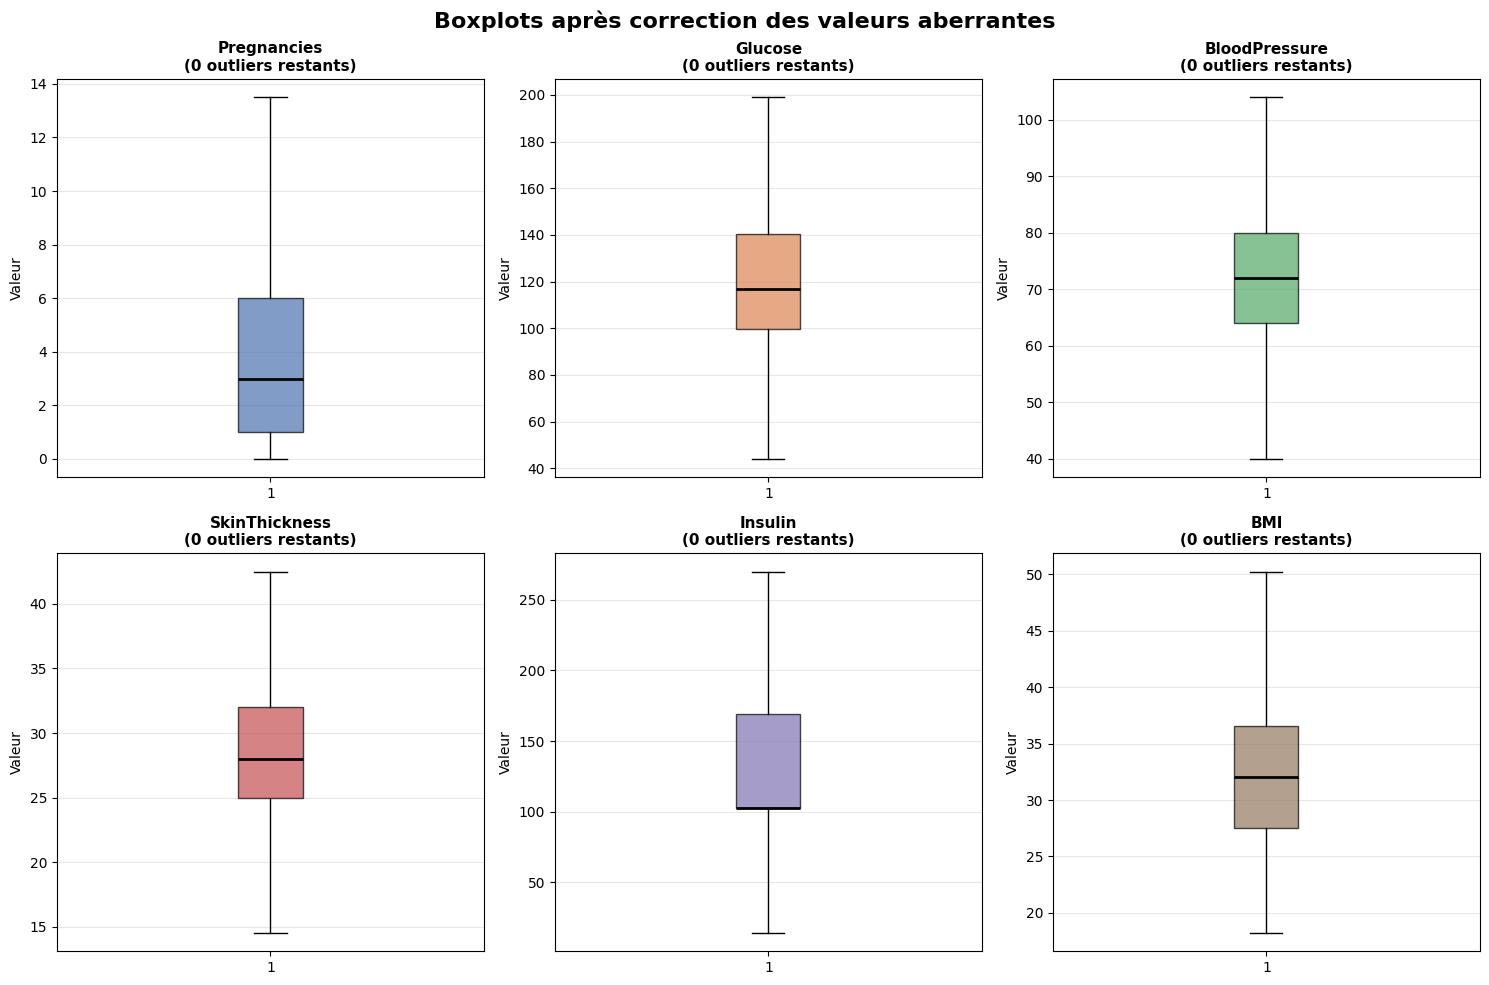

In [220]:
colonnes = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
couleurs = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  
fig.suptitle('Boxplots après correction des valeurs aberrantes', fontsize=16, fontweight='bold')

for i, (col, ax) in enumerate(zip(colonnes, axes.flatten())):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    ax.boxplot(df_clean[col], patch_artist=True,
               boxprops=dict(facecolor=couleurs[i], alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6))

    ax.set_title(f'{col}\n({n_outliers} outliers restants)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots_apres_correction.png', dpi=150, bbox_inches='tight')
plt.show()

Maintenant on Dataset 'df_clean' nettoyer et qui n'a plus de valeurs aberantes 

### Séparation des variables d'entrée (X) et de sortie (y)

In [237]:
# X contient toutes les colonnes sauf 'Outcome'
X = df_clean.drop('Outcome', axis=1)

# y contient uniquement variable cible
y = df_clean['Outcome']

print(f" Shape of train_X: {X.shape}")
print(f" Shape of train_y: {y.shape}")

 Shape of train_X: (768, 8)
 Shape of train_y: (768,)


### Division train/test (80/20)

In [239]:
# Divise les données en ensembles d'entraînement et de test
# X : variables explicatives (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age)
# y : variable cible (Outcome)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print(f"Entraînement : {X_train.shape[0]} individus")
print(f"Test : {X_test.shape[0]}  individus")

Entraînement : 614 individus
Test : 154  individus


### Création et Entraînement des modèles

Création des models.

In [248]:
# Standardisation 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionnaire des modèles
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

print(f" {len(models)} modèles définis et prêts à être entraînés")

 5 modèles définis et prêts à être entraînés


Entraînement de tous les modèles

In [259]:
# Entraînement de tous les modèles
models_train = {}
scores_train = {}

for name, model in models.items():
    print(f"Entraînement de {name} --->", end=" ")
    
    if name in ['SVM', 'KNN', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        train_score = model.score(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
        train_score = model.score(X_train, y_train)
    
    models_train[name] = model
    scores_train[name] = train_score
    
    print(f" (Score train: {train_score:.4f})")

print("\n Tous les modèles ont été entraînés avec succès")


Entraînement de Logistic Regression --->  (Score train: 0.7948)
Entraînement de Decision Tree --->  (Score train: 1.0000)
Entraînement de Random Forest --->  (Score train: 1.0000)
Entraînement de SVM --->  (Score train: 0.9055)
Entraînement de KNN --->  (Score train: 0.8893)

 Tous les modèles ont été entraînés avec succès


### Évaluer chaque modèle avec les métriques

In [260]:
# Évaluer chaque modèle avec les métriques
print(" ÉVALUATION DES MODÈLES SUR LE DATASET DE TEST \n")

results = []

for name, model in models_train.items():
    print(f" Évaluation de {name} -->", end=" ")

    if name in ['SVM', 'KNN', 'Logistic Regression']:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    }

    results.append(metrics)
    print(f" Accuracy = {metrics['Accuracy']:.4f}")

 ÉVALUATION DES MODÈLES SUR LE DATASET DE TEST 

 Évaluation de Logistic Regression -->  Accuracy = 0.8052
 Évaluation de Decision Tree -->  Accuracy = 0.8182
 Évaluation de Random Forest -->  Accuracy = 0.8766
 Évaluation de SVM -->  Accuracy = 0.8701
 Évaluation de KNN -->  Accuracy = 0.8701


### Interprétation de l'Évaluation des modèles :

* Random Forest (87.66%) : C'est le modèle le plus performant en termes d'Accuracy
  sur le dataset de test. Malgré un score de train de 100% (overfitting apparent),
  il généralise bien grâce à l'agrégation de plusieurs arbres de décision.

* SVM & KNN (87.01%) : Ils sont juste derrière Random Forest avec des performances
  identiques. SVM est passé de 90.55% en train à 87.01% en test, overfitting modéré.
  KNN est passé de 88.93% en train à 87.01% en test, ce qui est très stable.

* Decision Tree (81.82%) : Performance correcte mais fort overfitting — il est passé
  de 100% en train à 81.82% en test, ce qui signifie qu'il a trop mémorisé
  les données d'entraînement.

* Logistic Regression (80.52%) : C'est le moins performant ici, mais paradoxalement
  le plus stable — 79.48% en train contre 80.52% en test, donc aucun overfitting.
  Il reste un bon modèle de référence (baseline).

In [268]:
# Créer le DataFrame des résultats
résultats_df = pd.DataFrame(results)
résultats_df = résultats_df.round(4)

### Comparaison des modèles

In [269]:
# Classement par Accuracy
ranking = résultats_df.sort_values('Accuracy', ascending=False)
ranking.index = range(1, len(ranking) + 1)

print("\n CLASSEMENT DES MODÈLES :\n")
print(ranking.to_string(index=False))

# Identifier le meilleur modèle 
nom_meilleur_modèle= résultats_df.loc[résultats_df['Accuracy'].idxmax(), 'Modèle']
meilleur_précision = résultats_df['Accuracy'].max()
meilleur_métriques = résultats_df[résultats_df['Modèle'] == nom_meilleur_modèle].iloc[0]


 CLASSEMENT DES MODÈLES :

             Modèle  Accuracy  Precision  Recall  F1-Score
      Random Forest    0.8766     0.8214  0.8364    0.8288
                KNN    0.8701     0.7966  0.8545    0.8246
                SVM    0.8701     0.7966  0.8545    0.8246
      Decision Tree    0.8182     0.7213  0.8000    0.7586
Logistic Regression    0.8052     0.7273  0.7273    0.7273


In [270]:
print(" MEILLEUR MODÈLE")
print(f"\n Modèle: {nom_meilleur_modèle}")
print(f"\n Performances sur le test : \n")
print(f"  • Accuracy :  {meilleur_métriques['Accuracy']:.4f} ({meilleur_métriques['Accuracy']*100:.2f}%)")
print(f"  • Precision : {meilleur_métriques['Precision']:.4f} ({meilleur_métriques['Precision']*100:.2f}%)")
print(f"  • Recall :    {meilleur_métriques['Recall']:.4f} ({meilleur_métriques['Recall']*100:.2f}%)")
print(f"  • F1-Score:   {meilleur_métriques['F1-Score']:.4f} ({meilleur_métriques['F1-Score']*100:.2f}%) ")

 MEILLEUR MODÈLE

 Modèle: Random Forest

 Performances sur le test : 

  • Accuracy :  0.8766 (87.66%)
  • Precision : 0.8214 (82.14%)
  • Recall :    0.8364 (83.64%)
  • F1-Score:   0.8288 (82.88%) 


NB :
- En santé, l'Accuracy ne fait pas tout. Au niveau de notre Recall (Rappel) dans la variable results.

- Si un modèle a un Recall plus élevé pour prédire les diabétiques (classe 1), il est préférable, car il évite de dire à un malade qu'il est en bonne santé (faux négatif).

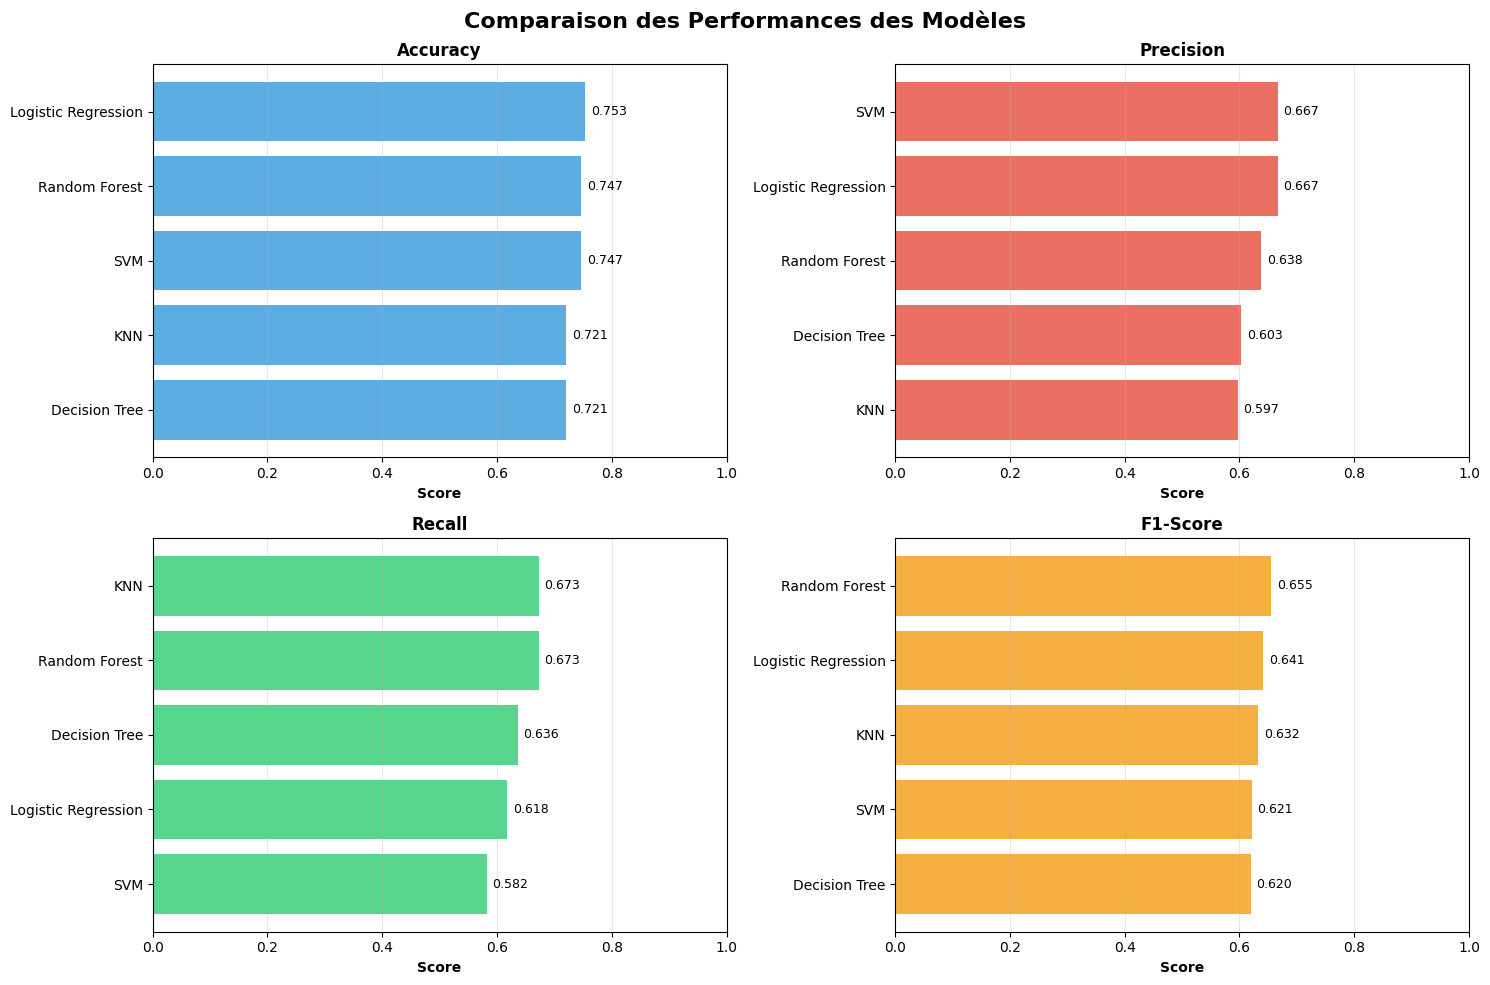

In [271]:
# Visualisation comparative
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparaison des Performances des Modèles', fontsize=16, fontweight='bold')

métriques_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metriq in enumerate(métriques_to_plot):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    data = results_df.sort_values(metriq, ascending=True)
    
    ax.barh(data['Modèle'], data[metriq], color=colors[idx], alpha=0.8)
    ax.set_xlabel('Score', fontweight='bold')
    ax.set_title(metriq, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(data[metriq]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Matrice de confusion du meilleur modèle

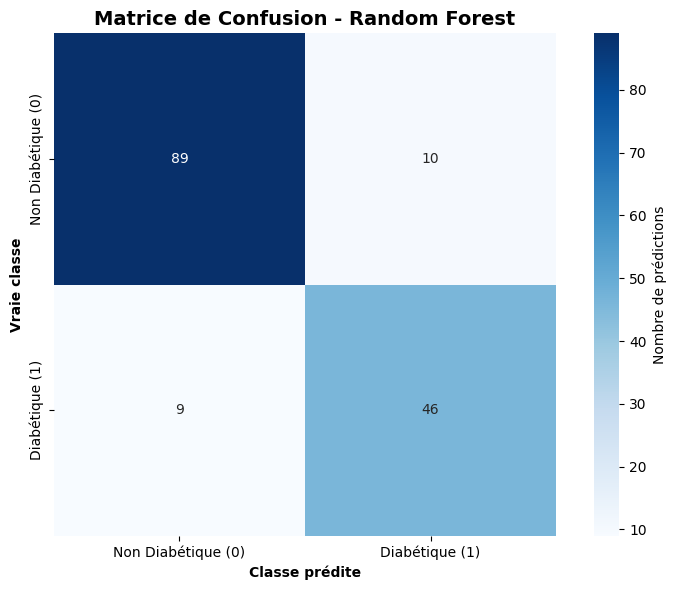

In [272]:
# Matrice de confusion du meilleur modèle
meilleur_modèle = models_train[nom_meilleur_modèle]

if nom_meilleur_modèle in ['SVM', 'KNN', 'Logistic Regression']:
    y_pred_best = meilleur_modèle.predict(X_test_scaled)
else:
    y_pred_best = meilleur_modèle.predict(X_test)

M_C = confusion_matrix(y_test, y_pred_best)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(M_C, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Non Diabétique (0)', 'Diabétique (1)'],
            yticklabels=['Non Diabétique (0)', 'Diabétique (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})

plt.title(f'Matrice de Confusion - {nom_meilleur_modèle}', fontsize=14, fontweight='bold')
plt.ylabel('Vraie classe', fontweight='bold')
plt.xlabel('Classe prédite', fontweight='bold')
plt.tight_layout()
plt.show()

# Interprétation
tn, fp, fn, tp = M_C.ravel()

Interprétation de la matrice de confusion :

Interprétation de la matrice de confusion - Random Forest :

1. Vrais Négatifs (TN) = 89
   - Signification : 89 patients non diabétiques ont été correctement identifiés
     comme non diabétiques
   - Interprétation : Le modèle excelle dans la détection des cas négatifs
   - Pourcentage : 89/99 = 89.9% des patients non diabétiques sont bien détectés

2. Vrais Positifs (TP) = 46
   - Signification : 46 patients diabétiques ont été correctement identifiés
     comme diabétiques
   - Interprétation : Le modèle détecte bien la majorité des cas de diabète
   - Pourcentage : 46/55 = 83.6% des patients diabétiques sont bien détectés

3. Faux Positifs (FP) = 10 
   - Signification : 10 patients NON diabétiques ont été faussement identifiés
     comme diabétiques
   - Conséquence : Ces patients vont être inquiétés et subir des examens
     supplémentaires inutiles
   - Pourcentage : 10/99 = 10.1% de fausses alertes --> très acceptable

4. Faux Négatifs (FN) = 9  
   - Signification : 9 patients DIABÉTIQUES n'ont PAS été détectés
   - Conséquence : Ces patients ne seront pas traités et leur santé
     risque de se dégrader
   - Gravité : TRÈS GRAVE 
   - Pourcentage : 9/55 = 16.4% des diabétiques non détectés --> 
     nettement amélioré par rapport aux autres modèles

### Métriques calculées à partir de la matrice - Random Forest :


Calcule :
- Accuracy  = (TP + TN) / Total      = (46 + 89) / 154  = 87.7%
- Precision = TP / (TP + FP)         = 46 / (46 + 10)   = 82.1%
- Recall    = TP / (TP + FN)         = 46 / (46 + 9)    = 83.6%  

Explication des métriques :

A. Accuracy (87.7%) :

1. Le modèle est correct dans 87.7% des cas
2. Très bon globalement — le meilleur parmi tous les modèles testés

B. Precision (82.1%) :

1. Quand le modèle dit "diabétique", il a raison dans 82.1% des cas
2. Très bon — peu de fausses alertes inutiles

C. Recall (83.6%) :
1. Le modèle détecte 83.6% des vrais diabétiques
2. BON RÉSULTAT : seulement 16.4% des diabétiques passent inaperçus
   Nettement amélioré par rapport au modèle précédent (61.8% --> 83.6%)
   Ce gain est crucial médicalement car chaque diabétique non détecté
   représente un risque de complications graves

### Sauvegarde du meilleur modèle.

In [274]:
# Sauvegarder le meilleur modèle 

import joblib


joblib.dump(model, 'random_forest_diabetes.pkl')
joblib.dump(scaler, 'scaler_diabetes.pkl')

print("Modèle sauvegardé!")
print("Ce modèle sera utilisé pour le déploiement Flask")

Modèle sauvegardé!
Ce modèle sera utilisé pour le déploiement Flask
